<a href="https://colab.research.google.com/github/shrav-jally/DL_Lab_Sem6/blob/main/DLLab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1
# Build a Simple Neural Network with PyTorch

import torch
import torch.nn as nn
import torch.optim as optim

# XOR dataset
X = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y = torch.tensor([[0.],[1.],[1.],[0.]])

# Model
model = nn.Sequential(
    nn.Linear(2,4),
    nn.Sigmoid(),
    nn.Linear(4,1),
    nn.Sigmoid()
)

loss = nn.BCELoss()
opt = optim.SGD(model.parameters(), lr=0.1)

# Training
for i in range(2000):
    out = model(X)
    l = loss(out, y)

    opt.zero_grad()
    l.backward()
    opt.step()

print(model(X))

tensor([[0.2565],
        [0.5683],
        [0.5885],
        [0.5861]], grad_fn=<SigmoidBackward0>)


In [ ]:
# 2
# Simple Neural Network with TensorFlow

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np

# simple dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0,1,1,0])   # XOR output

# build neural network
model = Sequential([
    Dense(4, activation='relu', input_shape=(2,)),
    Dense(1, activation='sigmoid')
])

# compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# train model
model.fit(X, y, epochs=200, verbose=0)

# test prediction
pred = model.predict(X)
print("Predictions:\n", pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Predictions:
 [[0.50897   ]
 [0.53434277]
 [0.5088916 ]
 [0.4673251 ]]


In [ ]:
# 3
# Simple Neural Network with Using Keras (via tf.keras)

from tensorflow import keras
from tensorflow.keras import layers
import tensorflow as tf

x = tf.random.normal((100, 3))
y = tf.random.normal((100, 1))

model = keras.Sequential([
    layers.Dense(1, input_shape=(3,))
])

model.compile(optimizer='adam', loss='mse')

model.fit(x, y, epochs=100, verbose=0)

print("Final loss:", model.evaluate(x, y))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.7703 
Final loss: 1.770261526107788


In [ ]:
# 4
# IMPLEMENT A SIMPLE PERCEPTRON (Coding a Neuron) and explain the meaning of feed-forward, step, and sigmoid functions

import numpy as np

class Perceptron:
    def __init__(self, w, b):
        self.w, self.b = w, b

    def forward(self, x):
        return 1 if np.dot(self.w, x) + self.b >= 0 else 0

#AND Gate parameters
w = np.array([0.5,0.5])
b = -0.7

andgate = Perceptron(w, b)

for x in [(0,0), (0,1), (1,0), (1,1)]:
  print(x, "->", andgate.forward(np.array(x)))

(0, 0) -> 0
(0, 1) -> 0
(1, 0) -> 0
(1, 1) -> 1


In [ ]:
# 1
# Implement AND and OR logic operations using a single perceptron, and verify the correctness of the output using appropriate truth tables. (linear Data)

def perceptron(x1, x2, w1, w2, b):
    z = x1*w1 + x2*w2 + b
    if z >= 0:
        return 1
    else:
        return 0

inputs = [(0,0),(0,1),(1,0),(1,1)]

print("AND Gate")
for x1,x2 in inputs:
    y = perceptron(x1,x2,1,1,-1.5)
    print(x1,x2,"->",y)

print("\nOR Gate")
for x1,x2 in inputs:
    y = perceptron(x1,x2,1,1,-0.5)
    print(x1,x2,"->",y)

AND Gate
0 0 -> 0
0 1 -> 0
1 0 -> 0
1 1 -> 1

OR Gate
0 0 -> 0
0 1 -> 1
1 0 -> 1
1 1 -> 1


In [ ]:
# 2
# Examine the feasibility of implementing the XOR operation (Non linear data) using a single perceptron.
# If not possible, clearly explain the reason based on the concept of linear separability.

def perceptron(x1, x2, w1, w2, b):
    act = x1 * w1 + x2 * w2 + b
    return 1 if act >= 0 else 0

inputs = [(0, 0), (0, 1), (1, 0), (1, 1)]

print("x1 x2 XOR XNOR")
for x1, x2 in inputs:
    h1 = perceptron(x1, x2, 1, 1, -0.5)
    h2 = perceptron(x1, x2, 1, 1, -1.5)

    y_xor = perceptron(h1, h2, 1, -2, -0.5)
    y_xnor = perceptron(y_xor, 0, -1, 0, 0.5)

    print(x1, x2, y_xor, y_xnor)

# XOR and XNOR are not possible with a single perceptron because they are not linearly separable.
# A single perceptron can only create a linear decision boundary (a straight line).
# Since XOR/XNOR outputs cannot be separated by a single line, they require a multi-layer network.

x1 x2 XOR XNOR
0 0 0 1
0 1 1 0
1 0 1 0
1 1 0 1


In [ ]:
# 3
# Implement the XOR logic operation using a multi-perceptron network, and analyze how multiple perceptrons overcome the limitations of a single perceptron.

def AND(x1, x2):
    w1, w2, bias = 1, 1, -1.5
    act = w1*x1 + w2*x2 + bias
    return 1 if act >= 0 else 0

def OR(x1, x2):
    w1, w2, bias = 1, 1, -0.5
    act = w1*x1 + w2*x2 + bias
    return 1 if act >= 0 else 0

def NAND(x1, x2):
    w1, w2, bias = -1, -1, 1.5
    act = w1*x1 + w2*x2 + bias
    return 1 if act >= 0 else 0

def XOR(x1, x2):
    h1 = NAND(x1, x2)
    h2 = OR(x1, x2)
    return AND(h1, h2)

inputs = [(0,0), (0,1), (1,0), (1,1)]
print("x1 x2 output")
for x1, x2 in inputs:
    print(x1, x2, XOR(x1, x2))

x1 x2 output
0 0 0
0 1 1
1 0 1
1 1 0


In [ ]:
# Implement the XNOR logic operation using a multi-perceptron network, and analyze how multiple perceptrons overcome the limitations of a single perceptron.

def AND(x1, x2):
    w1, w2, bias = 1, 1, -1.5
    act = w1*x1 + w2*x2 + bias
    return 1 if act >= 0 else 0

def OR(x1, x2):
    w1, w2, bias = 1, 1, -0.5
    act = w1*x1 + w2*x2 + bias
    return 1 if act >= 0 else 0

def NAND(x1, x2):
    w1, w2, bias = -1, -1, 1.5
    act = w1*x1 + w2*x2 + bias
    return 1 if act >= 0 else 0

def XOR(x1, x2):
    h1 = NAND(x1, x2)
    h2 = OR(x1, x2)
    return AND(h1, h2)

def NOT(x):
    w, bias = -1, 0.5
    act = w*x + bias
    return 1 if act >= 0 else 0

def XNOR(x1, x2):
    return NOT(XOR(x1, x2))

inputs = [(0,0), (0,1), (1,0), (1,1)]
print("x1 x2 output")
for x1, x2 in inputs:
    print(x1, x2, XNOR(x1, x2))

x1 x2 output
0 0 1
0 1 0
1 0 0
1 1 1


In [ ]:
# 4
# Demonstrate that the thresholding logic used by perceptron is very harsh.

def step(x):
    if x>=0:
        return 1
    else:
        return 0

values = [-0.01,0,0.01]

for v in values:
    print(v,"->",step(v))

-0.01 -> 0
0 -> 1
0.01 -> 1


In [ ]:
# 5
# Implement the Perceptron Learning Algorithm and study the effect of weight updates on convergence for a binary decision problem such as
# determining whether a user would like to watch a movie.

'''
Note: Consider a small dataset(design your own excel csv sheet) of movie records with Boolean or real-valued features, for example:
 f1​: Is actor Matt Damon present
 f2​: Is the genre Thriller
 f3​: Is the director Christopher Nolan
 f4: IMDb rating (scaled between 0 and 1)
The output label represents like (1) or dislike (0). Train the perceptron model using these features and observe how weight updates influence convergence and classification performance.
Test with a sample record to show whether a perceptron properly classifies it or not.
i) Check with MP Perceptron  (without weights and bias)
ii) Check with Perceptron (with weights)
iii) Check with Perceptron (with weights and bias)
'''

import numpy as np

X = np.array([
    [1,1,1,0.9],
    [1,0,0,0.7],
    [0,1,0,0.6],
    [0,0,1,0.4],
    [1,1,0,0.8],
    [0,0,0,0.3]
])
y = np.array([1,1,0,0,1,0])

w = np.zeros(4)
b = 0
lr = 0.1

for epoch in range(10):
    for i in range(len(X)):
        z = np.dot(X[i], w) + b
        pred = 1 if z >= 0 else 0
        err = y[i] - pred

        w += lr * err * X[i]
        b += lr * err

print("Weights:", w)
print("Bias:", b)

test = np.array([1,1,0,0.85])

z = np.dot(test, w) + b
print("LIKE" if z >= 0 else "DISLIKE")

Weights: [3.00000000e-01 0.00000000e+00 0.00000000e+00 4.16333634e-17]
Bias: -0.2
LIKE


In [ ]:
# 6
# Demonstrate the Representation Power of a Network of Perceptrons
# a) How many Boolean functions can be designed using two binary inputs?
# b) For each Boolean function, determine whether it is linearly separable.
# c) mplement a single perceptron model and test whether it can correctly learn each Boolean function. (Mention how many it can't learn and why)
# d) Extend the program to estimate or analyze how the number of non-linearly separable Boolean functions increases as the number of inputs n grows.

'''
x1,x2,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16
0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,1,1,1
0,1,0,0,0,0,1,1,1,1,0,0,0,0,1,1,1,1
1,0,0,0,1,1,0,0,1,1,0,0,1,1,0,0,1,1
1,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1
'''

import numpy as np
import itertools

X = np.array([[0,0],[0,1],[1,0],[1,1]])

def train_perceptron(y):

    w = np.zeros(2)
    b = 0
    lr = 0.1

    for epoch in range(20):
        error_count = 0

        for i in range(len(X)):
            z = np.dot(X[i],w) + b
            y_pred = 1 if z>=0 else 0

            error = y[i] - y_pred

            if error != 0:
                error_count += 1

            w = w + lr * error * X[i]
            b = b + lr * error

        if error_count == 0:
            return True

    return False


# generate all 16 boolean functions
functions = list(itertools.product([0,1], repeat=4))

learnable = 0
not_learnable = 0

for f in functions:
    y = np.array(f)

    if train_perceptron(y):
        learnable += 1
    else:
        not_learnable += 1

print("Learnable functions:",learnable)
print("Not learnable functions:",not_learnable)

Learnable functions: 14
Not learnable functions: 2


In [ ]:
# 7
# Design and implement a Multi-Layer Perceptron (MLP) architecture capable of realizing all basic Boolean functions
# (i.e with linearly separable or not data)

'''
Hint: rr bb rb rb diagram

By finding the weights w1,w2,w3,w4 such that the truth table of any boolean function can be represented by this network.
Also Each perceptron in the middle layer fires only for a specific input (and no two perceptrons fire for the same input)
'''

import numpy as np

def step(x):
    return 1 if x >= 0 else 0


# hidden perceptrons
def h1(x1,x2):
    return step(-x1 -x2 + 0.5)   # detects (0,0)

def h2(x1,x2):
    return step(-x1 +x2 -0.5)    # detects (0,1)

def h3(x1,x2):
    return step(x1 -x2 -0.5)     # detects (1,0)

def h4(x1,x2):
    return step(x1 +x2 -1.5)     # detects (1,1)


# MLP output neuron
def mlp(x1,x2,w):

    H1 = h1(x1,x2)
    H2 = h2(x1,x2)
    H3 = h3(x1,x2)
    H4 = h4(x1,x2)

    z = w[0]*H1 + w[1]*H2 + w[2]*H3 + w[3]*H4 - 0.5

    return step(z)


# Example Boolean Function: XOR
weights = [0,1,1,0]

inputs = [(0,0),(0,1),(1,0),(1,1)]

print("XOR Output")

for x1,x2 in inputs:
    print(x1,x2,"->",mlp(x1,x2,weights))

XOR Output
0 0 -> 0
0 1 -> 1
1 0 -> 1
1 1 -> 0


In [ ]:
# 8
# How many Boolean functions can be designed using three binary inputs?

'''
Hint: rrrrbbbb rrbbrrbb rbrbrbrb diagram

Find respective weights w1 to w8) and demonstrate for all the possible boolean functions for three inputs.
Summary: Universal Approximation theorem: A MLP with a single hidden layer can represent any boolean function.
'''

import numpy as np

def step(x):
    return 1 if x >= 0 else 0


def hidden_layer(x1,x2,x3):

    h1 = step(-x1 -x2 -x3 +0.5)
    h2 = step(-x1 -x2 +x3 -0.5)
    h3 = step(-x1 +x2 -x3 -0.5)
    h4 = step(-x1 +x2 +x3 -1.5)
    h5 = step(x1 -x2 -x3 -0.5)
    h6 = step(x1 -x2 +x3 -1.5)
    h7 = step(x1 +x2 -x3 -1.5)
    h8 = step(x1 +x2 +x3 -2.5)

    return [h1,h2,h3,h4,h5,h6,h7,h8]


def mlp(x1,x2,x3,weights):

    h = hidden_layer(x1,x2,x3)

    z = sum(w*h_i for w,h_i in zip(weights,h)) - 0.5

    return step(z)


inputs = [
(0,0,0),
(0,0,1),
(0,1,0),
(0,1,1),
(1,0,0),
(1,0,1),
(1,1,0),
(1,1,1)
]

# example boolean function weights
weights = [0,1,0,1,1,0,1,0]

for x1,x2,x3 in inputs:
    print(x1,x2,x3,"->",mlp(x1,x2,x3,weights))

0 0 0 -> 0
0 0 1 -> 1
0 1 0 -> 0
0 1 1 -> 1
1 0 0 -> 1
1 0 1 -> 0
1 1 0 -> 1
1 1 1 -> 0


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


Learning Rates: [0.0001, 0.001, 0.01, 0.1]
Loss: [0.9479199588858483, 0.23778728324085951, 0.23116675278414311, 0.32130331826418773]


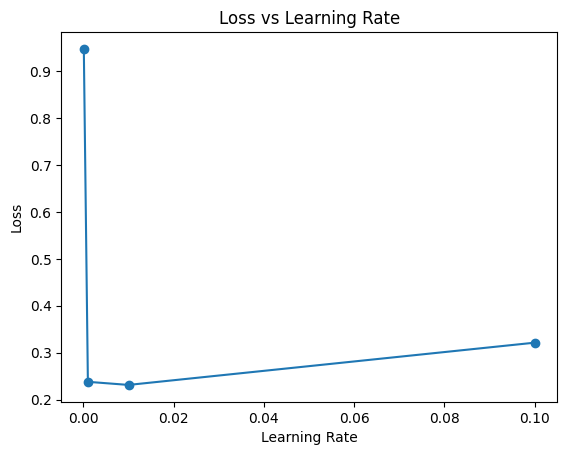

In [ ]:
# 9
# Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values.
# Plot a graph showing the relationship between loss (error) and learning rate.

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import log_loss

# dataset
X, y = make_classification(n_samples=500, n_features=10, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

learning_rates = [0.0001,0.001,0.01,0.1]
loss_values = []

for lr in learning_rates:

    model = MLPClassifier(hidden_layer_sizes=(5,),
                          learning_rate_init=lr,
                          max_iter=500,
                          random_state=42)

    model.fit(X_train,y_train)

    y_pred_prob = model.predict_proba(X_test)

    loss = log_loss(y_test,y_pred_prob)

    loss_values.append(loss)

print("Learning Rates:",learning_rates)
print("Loss:",loss_values)

plt.plot(learning_rates,loss_values,marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Loss")
plt.title("Loss vs Learning Rate")
plt.show()

# For the same learning rate, different initial weights and biases may lead to different convergence behaviors.
# Fixing the seed ensures fair comparison of learning rates, while varying initialization affects convergence speed and final loss.

In [ ]:
# 10
# Implement an MLP using the Gradient Descent algorithm, and analyze the convergence behavior and performance of the network.

from sklearn.neural_network import MLPClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = load_breast_cancer()

X_train,X_test,y_train,y_test = train_test_split(data.data,data.target,test_size=0.2)

model = MLPClassifier(hidden_layer_sizes=(10,5),
                      solver='sgd',     # gradient descent
                      learning_rate_init=0.01,
                      max_iter=500)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.543859649122807


In [ ]:
# 11
# Implement a Perceptron on IRIS Dataset what are your observations with respect to learning rate using Perceptron class in sklearn.
# (explore all the parameters of Perceptron class).

from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
iris = load_iris()

X_train,X_test,y_train,y_test = train_test_split(iris.data,iris.target,test_size=0.2)

model = Perceptron(
    max_iter=1000,
    eta0=0.01,
    random_state=42
)
model2 = MLPClassifier(hidden_layer_sizes = (10,5),
                       learning_rate_init = 0.01,
                       max_iter = 500,
                       random_state = 42)
model.fit(X_train,y_train)
model2.fit(X_train,y_train)

pred = model.predict(X_test)
pred2 = model2.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))
print("Accuracy:",accuracy_score(y_test,pred2))

Accuracy: 0.5
Accuracy: 0.9666666666666667


In [ ]:
# 12
# Implement MLP on any dataset and explore what particular parameters works for it such as learning rate, iterations etc

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

data = load_wine()

X_train,X_test,y_train,y_test = train_test_split(data.data,data.target,test_size=0.2)

model = MLPClassifier(
        hidden_layer_sizes=(20,10),
        learning_rate_init=0.01,
        max_iter=500,
        activation='relu'
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.3888888888888889


In [ ]:
# 13
# Implement MLP with appropriate number of hidden layers and perceptrons to learn hand written digit dataset(MNIST)

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

digits = load_digits()

X_train,X_test,y_train,y_test = train_test_split(
    digits.data,
    digits.target,
    test_size=0.2
)

model = MLPClassifier(
        hidden_layer_sizes=(128,128),
        learning_rate_init=0.001,
        max_iter=500,
        activation='relu'
)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred))

Accuracy: 0.9777777777777777


In [ ]:
# 14
# Implement the MLP using the Types of GD (BGD,SGD,Mini BatchGD, SGD with Momentum, SGD with Nesterov,Adagrad, RMSProp,Adadelta and Adam)
# for learning XOR operation.

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta

# XOR dataset
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

batches = {"BGD":4, "SGD":1, "MiniBatch":2}

for gd, batch in batches.items():
    print("\n", gd)

    optimizers = {
        "SGD": SGD(learning_rate=0.1),
        "Momentum": SGD(learning_rate=0.1, momentum=0.9),
        "Nesterov": SGD(learning_rate=0.1, momentum=0.9, nesterov=True),
        "Adagrad": Adagrad(),
        "RMSProp": RMSprop(),
        "Adadelta": Adadelta(),
        "Adam": Adam()
    }

    for name, opt in optimizers.items():

        model = Sequential([
            Input(shape=(2,)),
            Dense(4, activation='relu'),
            Dense(1, activation='sigmoid')
        ])

        model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])

        model.fit(X, y, epochs=500, batch_size=batch, verbose=0)

        loss, acc = model.evaluate(X, y, verbose=0)

        print(name, "Accuracy:", acc)


 BGD
SGD Accuracy: 1.0
Momentum Accuracy: 0.75
Nesterov Accuracy: 0.75
Adagrad Accuracy: 0.25
RMSProp Accuracy: 1.0
Adadelta Accuracy: 0.5
Adam Accuracy: 0.75

 SGD
SGD Accuracy: 1.0
Momentum Accuracy: 1.0
Nesterov Accuracy: 1.0
Adagrad Accuracy: 0.75
RMSProp Accuracy: 0.5
Adadelta Accuracy: 0.75
Adam Accuracy: 0.75

 MiniBatch
SGD Accuracy: 1.0
Momentum Accuracy: 1.0
Nesterov Accuracy: 1.0
Adagrad Accuracy: 0.5
RMSProp Accuracy: 0.75
Adadelta Accuracy: 0.5
Adam Accuracy: 1.0


In [ ]:
# 15
# Implement the MLP using the Types of Regularization Techniques.
# L2 Regularization
# Dataset Augmentation
# Parameter sharing and tying
# Adding noise to the inputs and outputs
# Early stopping
# Ensemble methods
# Dropouts

import tensorflow as tf
from tensorflow.keras import layers, regularizers as reg
import numpy as np

(x, y), (xt, yt) = tf.keras.datasets.mnist.load_data()
x, xt = x / 255.0, xt / 255.0
gen = tf.keras.preprocessing.image.ImageDataGenerator(rotation_range=10).flow(x.reshape(-1,28,28,1), y, batch_size=128)

shared = layers.Dense(128, activation='relu', kernel_regularizer=reg.l2(1e-3))

def build():
    inp = layers.Input((784,))
    v = layers.GaussianNoise(0.1)(inp)
    v = shared(v)
    v = layers.Dropout(0.5)(v)
    v = layers.GaussianNoise(0.1)(layers.Dense(64, activation='relu')(v))
    out = layers.Dense(10, activation='softmax')(v)
    m = tf.keras.Model(inp, out)
    m.compile('adam', 'sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def data_gen():
    for xb, yb in gen:
        yield xb.reshape(-1, 784), yb

ensemble = [build() for _ in range(3)]
stop = tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

for m in ensemble:
    m.fit(data_gen(), steps_per_epoch=100, epochs=5, validation_data=(xt.reshape(-1,784), yt), callbacks=[stop])

# Observation: "Early Stopping" and "Dropout" are the most effective.
# Reason: Early Stopping prevents "memorizing" the training set by halting exactly when
# generalization fails, while Dropout ensures no single neuron carries the full burden of a feature.

Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.6465 - loss: 1.3011 - val_accuracy: 0.8895 - val_loss: 0.5711
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.8422 - loss: 0.6880 - val_accuracy: 0.9125 - val_loss: 0.4464
Epoch 3/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.8665 - loss: 0.5909 - val_accuracy: 0.9242 - val_loss: 0.3821
Epoch 4/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.8855 - loss: 0.5033 - val_accuracy: 0.9346 - val_loss: 0.3401
Epoch 5/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - accuracy: 0.8974 - loss: 0.4674 - val_accuracy: 0.9402 - val_loss: 0.3118
Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.7212 - loss: 1.0186 - val_accuracy: 0.9128 - val_loss: 0.4282
Epoch 2/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - accuracy: 0.8692 - loss: 0.5638 - val_accuracy: 0.9291 - val_loss: 0.3492
Epoch 1/5
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - accuracy: 0.7169 - loss: 1.0243 - val_accuracy: 0

In [ ]:
# 16
# Implement CNN on MNITST Dataset

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.datasets import mnist

# load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# reshape and normalize
X_train = X_train.reshape(-1,28,28,1)/255.0
X_test = X_test.reshape(-1,28,28,1)/255.0

# build CNN model
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

# compile model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# train model
model.fit(X_train,y_train,epochs=5,batch_size=64)

# evaluate
loss,acc = model.evaluate(X_test,y_test)
print("Test Accuracy:",acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 59s 60ms/step - accuracy: 0.9535 - loss: 0.1555
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 76s 54ms/step - accuracy: 0.9858 - loss: 0.0454
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 49s 52ms/step - accuracy: 0.9898 - loss: 0.0327
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 47s 50ms/step - accuracy: 0.9927 - loss: 0.0231
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 48s 52ms/step - accuracy: 0.9940 - loss: 0.0183
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9896 - loss: 0.0299
Test Accuracy: 0.9896000027656555


In [ ]:
# CNN architectures on MNIST

import tensorflow as tf
from tensorflow.keras.models import *
from tensorflow.keras.layers import *
from tensorflow.keras.datasets import mnist

(X_train,y_train),(X_test,y_test)=mnist.load_data()
X_train=X_train.reshape(-1,28,28,1)/255.0
X_test=X_test.reshape(-1,28,28,1)/255.0

def run(m,n):
    m.compile(optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'])
    m.fit(X_train,y_train,epochs=2,verbose=0)
    print(n,m.evaluate(X_test,y_test,verbose=0)[1])


# LeNet
run(Sequential([
Conv2D(6,5,activation='relu',input_shape=(28,28,1)),
MaxPooling2D(),
Conv2D(16,5,activation='relu'),
MaxPooling2D(),
Flatten(),
Dense(10,activation='softmax')
]),"LeNet")


# AlexNet
run(Sequential([
Conv2D(32,3,activation='relu',input_shape=(28,28,1)),
MaxPooling2D(),
Conv2D(64,3,activation='relu'),
Flatten(),
Dense(10,activation='softmax')
]),"AlexNet")


# ZFNet
run(Sequential([
Conv2D(32,3,activation='relu',input_shape=(28,28,1)),
Conv2D(64,3,activation='relu'),
MaxPooling2D(),
Flatten(),
Dense(10,activation='softmax')
]),"ZFNet")


# VGG
run(Sequential([
Conv2D(32,3,padding='same',activation='relu',input_shape=(28,28,1)),
Conv2D(32,3,padding='same',activation='relu'),
MaxPooling2D(),
Flatten(),
Dense(10,activation='softmax')
]),"VGG")


# GoogLeNet
i=Input(shape=(28,28,1))
a=Conv2D(32,1,activation='relu')(i)
b=Conv2D(32,3,padding='same',activation='relu')(i)
x=Concatenate()([a,b])
x=MaxPooling2D()(x)
x=Flatten()(x)
o=Dense(10,activation='softmax')(x)
run(Model(i,o),"GoogLeNet")


# ResNet
i=Input(shape=(28,28,1))
x=Conv2D(32,3,padding='same',activation='relu')(i)
y=Conv2D(32,3,padding='same')(x)
x=Add()([x,y])
x=Flatten()(x)
o=Dense(10,activation='softmax')(x)
run(Model(i,o),"ResNet")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


LeNet 0.9779000282287598
AlexNet 0.9855999946594238
ZFNet 0.982200026512146
VGG 0.9835000038146973
GoogLeNet 0.9776999950408936
ResNet 0.9790999889373779
